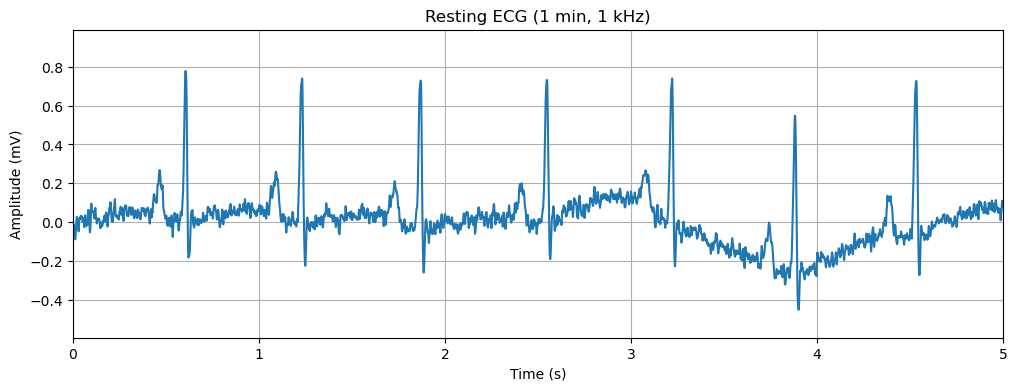

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Read file as raw text
with open("01_ECG_1min_1KHz-Rest.txt", "r") as f:
    text = f.read()

# Step 2: Replace comma decimal with dot
text = text.replace(",", ".")

# Step 3: Convert text to numpy array
from io import StringIO
ecg_data = np.loadtxt(StringIO(text))

# Sampling frequency
fs = 1000  # Hz
t = np.arange(len(ecg_data)) / fs

# Plot ECG
plt.figure(figsize=(12, 4))
plt.plot(t, ecg_data)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Resting ECG (1 min, 1 kHz)")
plt.xlim(0, 5)  # show first 5 seconds
plt.grid(True)
plt.show()


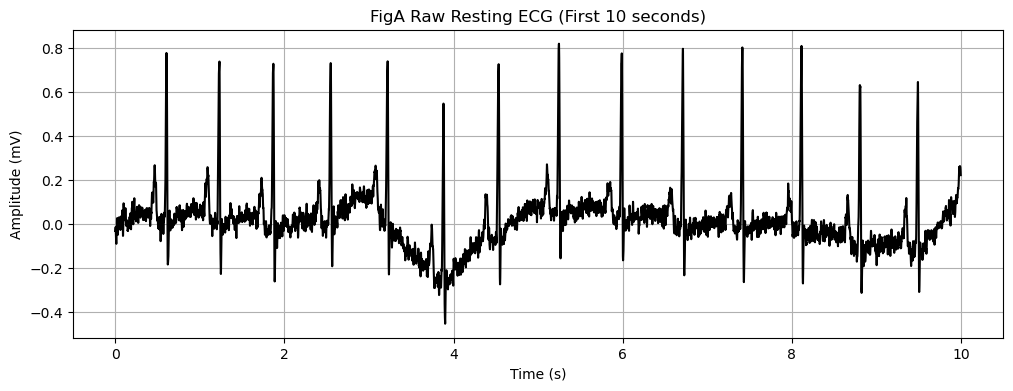

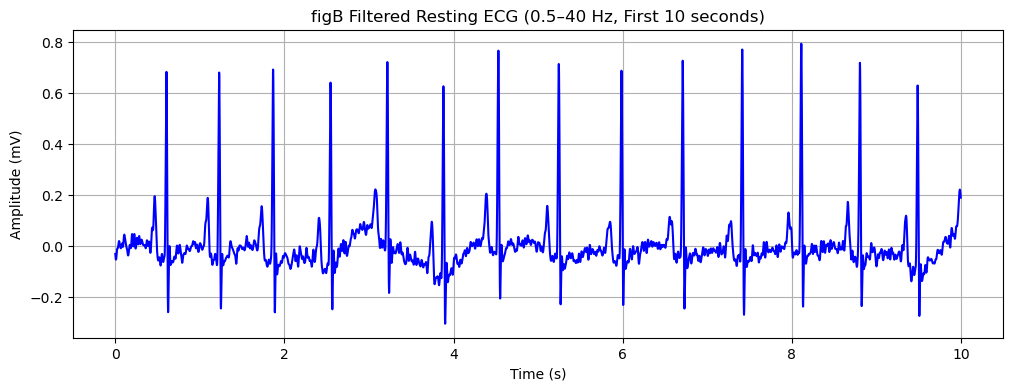

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --------------------------------------------------
# STEP 1: Load raw ECG safely (DO NOT MODIFY RAW)
# --------------------------------------------------
with open("01_ECG_1min_1KHz-Rest.txt", "r") as f:
    text = f.read()

# Convert European decimal commas to dots
text = text.replace(",", ".")

# Convert to numeric array
raw_ecg = np.array([float(x) for x in text.split()])

# Sampling frequency
fs = 1000  # Hz

# Time axis
time = np.arange(len(raw_ecg)) / fs

# --------------------------------------------------
# STEP 2: Plot RAW ECG (first 5 seconds)
# --------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(time[:10000], raw_ecg[:10000], color="black")
plt.title("FigA Raw Resting ECG (First 10 seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

# --------------------------------------------------
# STEP 3: Copy ECG for processing (SAFE PRACTICE)
# --------------------------------------------------
processed_ecg = raw_ecg.copy()

# --------------------------------------------------
# STEP 4: Band-pass filter (0.5–40 Hz)
# --------------------------------------------------
lowcut = 0.5
highcut = 40
order = 4

b, a = butter(
    order,
    [lowcut / (fs / 2), highcut / (fs / 2)],
    btype="band"
)

filtered_ecg = filtfilt(b, a, processed_ecg)

# --------------------------------------------------
# STEP 5: Plot FILTERED ECG (first 5 seconds)
# --------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(time[:10000], filtered_ecg[:10000], color="blue")
plt.title("figB Filtered Resting ECG (0.5–40 Hz, First 10 seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()


Samples: 60000
Duration: 60.00 s


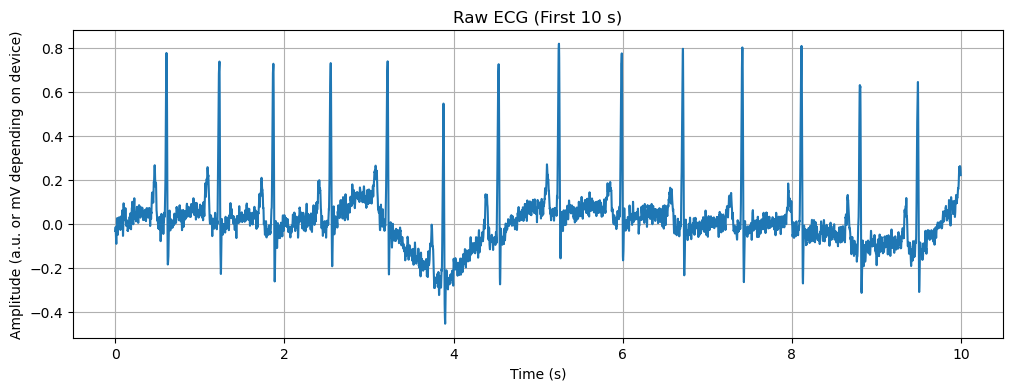

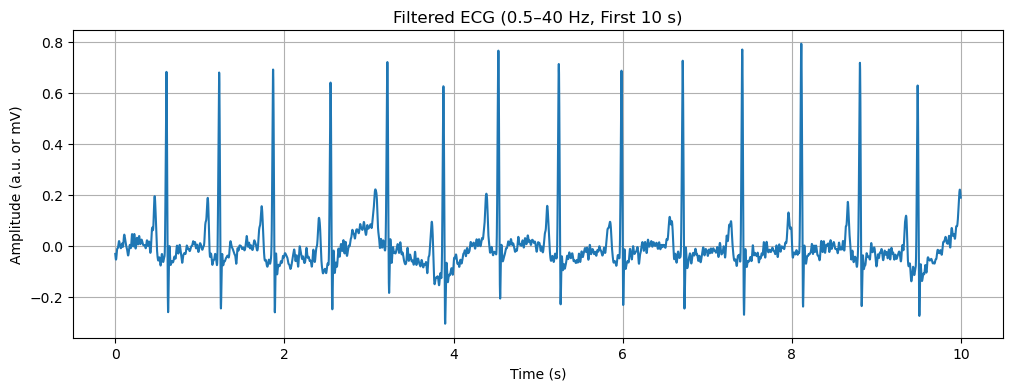

Detected beats: 90
Mean HR: 91.6 bpm
Min HR:  71.9 bpm
Max HR:  111.9 bpm
Mean RR: 660.6 ms


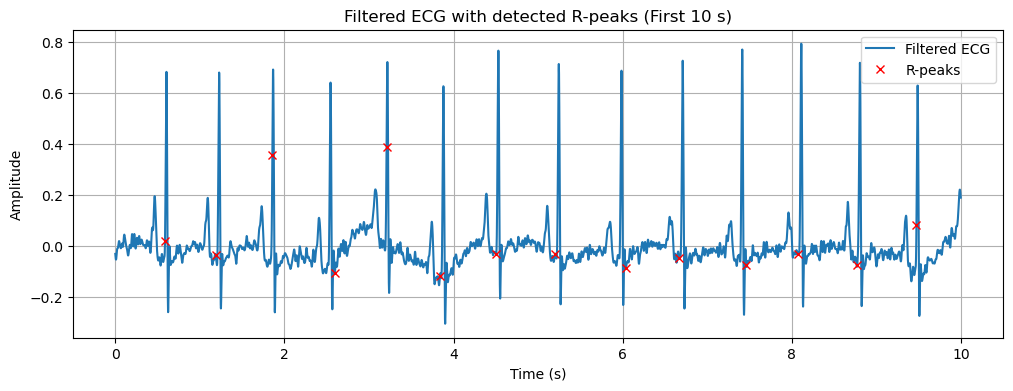

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# -----------------------------
# 1) Load ECG safely (comma decimals)
# -----------------------------
file_path = "01_ECG_1min_1kHz-Rest.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

text = text.replace(",", ".")                 # convert comma decimals to dot
raw_ecg = np.array([float(x) for x in text.split()])

fs = 1000  # Hz
t = np.arange(len(raw_ecg)) / fs

print(f"Samples: {len(raw_ecg)}")
print(f"Duration: {len(raw_ecg)/fs:.2f} s")

# -----------------------------
# 2) Bandpass filter (0.5–40 Hz)
# -----------------------------
lowcut = 0.5
highcut = 40
order = 4

b, a = butter(order, [lowcut/(fs/2), highcut/(fs/2)], btype="band")
filtered_ecg = filtfilt(b, a, raw_ecg)

# -----------------------------
# 3) Plot raw vs filtered (first 10 s)
# -----------------------------
N = int(10 * fs)

plt.figure(figsize=(12, 4))
plt.plot(t[:N], raw_ecg[:N])
plt.title("Raw ECG (First 10 s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u. or mV depending on device)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t[:N], filtered_ecg[:N])
plt.title("Filtered ECG (0.5–40 Hz, First 10 s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u. or mV)")
plt.grid(True)
plt.show()

# -----------------------------
# 4) Simple R-peak detection -> HR estimate
#    (robust enough for a quick HR/RR table)
# -----------------------------
# Enhance QRS: derivative squared + moving window integration
diff = np.diff(filtered_ecg, prepend=filtered_ecg[0])
sq = diff**2
win = int(0.150 * fs)  # 150 ms
mwi = np.convolve(sq, np.ones(win)/win, mode="same")

# Find peaks (distance >= 0.3 s => max 200 bpm)
peaks, props = find_peaks(mwi, distance=int(0.3*fs), prominence=np.percentile(mwi, 95)*0.1)

# RR intervals and HR
rr = np.diff(peaks) / fs
hr = 60 / rr

print(f"Detected beats: {len(peaks)}")
if len(hr) > 0:
    print(f"Mean HR: {hr.mean():.1f} bpm")
    print(f"Min HR:  {hr.min():.1f} bpm")
    print(f"Max HR:  {hr.max():.1f} bpm")
    print(f"Mean RR: {rr.mean()*1000:.1f} ms")

# Plot R-peaks over filtered ECG (first 10 s)
peaks_10s = peaks[peaks < N]

plt.figure(figsize=(12, 4))
plt.plot(t[:N], filtered_ecg[:N], label="Filtered ECG")
plt.plot(t[peaks_10s], filtered_ecg[peaks_10s], "rx", label="R-peaks")
plt.title("Filtered ECG with detected R-peaks (First 10 s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()


Samples: 60000
Duration: 60.00 s


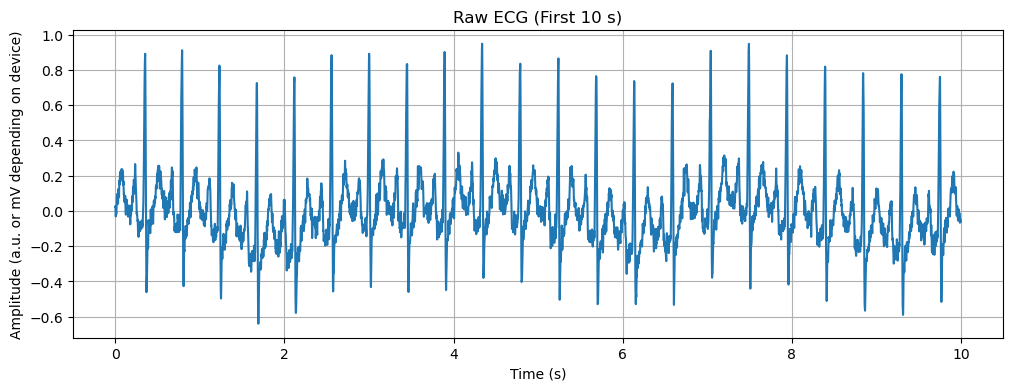

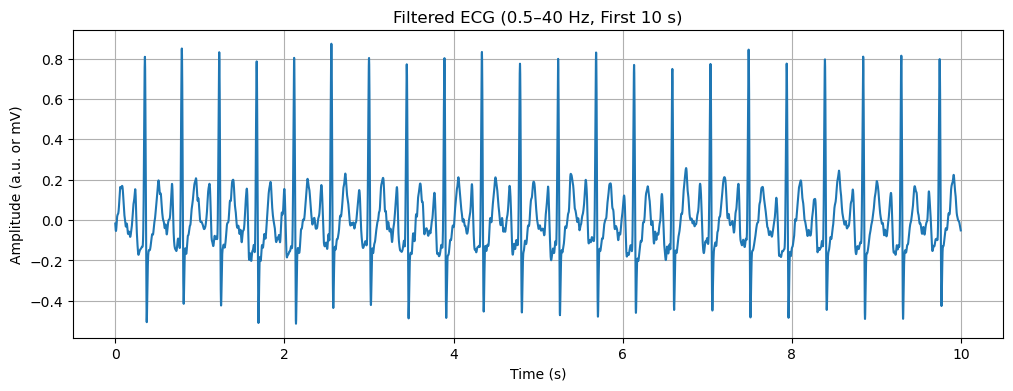

Detected beats: 125
Mean HR: 126.5 bpm
Min HR:  102.7 bpm
Max HR:  159.6 bpm
Mean RR: 478.5 ms


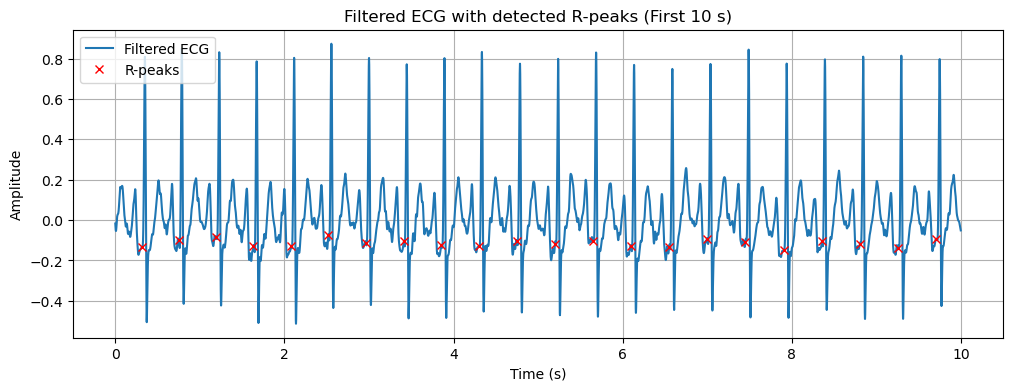

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# -----------------------------
# 1) Load ECG safely (comma decimals)
# -----------------------------
file_path = "02_ECG_1min_1kHz-Stress.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

text = text.replace(",", ".")                 # convert comma decimals to dot
raw_ecg = np.array([float(x) for x in text.split()])

fs = 1000  # Hz
t = np.arange(len(raw_ecg)) / fs

print(f"Samples: {len(raw_ecg)}")
print(f"Duration: {len(raw_ecg)/fs:.2f} s")

# -----------------------------
# 2) Bandpass filter (0.5–40 Hz)
# -----------------------------
lowcut = 0.5
highcut = 40
order = 4

b, a = butter(order, [lowcut/(fs/2), highcut/(fs/2)], btype="band")
filtered_ecg = filtfilt(b, a, raw_ecg)

# -----------------------------
# 3) Plot raw vs filtered (first 10 s)
# -----------------------------
N = int(10 * fs)

plt.figure(figsize=(12, 4))
plt.plot(t[:N], raw_ecg[:N])
plt.title("Raw ECG (First 10 s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u. or mV depending on device)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t[:N], filtered_ecg[:N])
plt.title("Filtered ECG (0.5–40 Hz, First 10 s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u. or mV)")
plt.grid(True)
plt.show()

# -----------------------------
# 4) Simple R-peak detection -> HR estimate
#    (robust enough for a quick HR/RR table)
# -----------------------------
# Enhance QRS: derivative squared + moving window integration
diff = np.diff(filtered_ecg, prepend=filtered_ecg[0])
sq = diff**2
win = int(0.150 * fs)  # 150 ms
mwi = np.convolve(sq, np.ones(win)/win, mode="same")

# Find peaks (distance >= 0.3 s => max 200 bpm)
peaks, props = find_peaks(mwi, distance=int(0.3*fs), prominence=np.percentile(mwi, 95)*0.1)

# RR intervals and HR
rr = np.diff(peaks) / fs
hr = 60 / rr

print(f"Detected beats: {len(peaks)}")
if len(hr) > 0:
    print(f"Mean HR: {hr.mean():.1f} bpm")
    print(f"Min HR:  {hr.min():.1f} bpm")
    print(f"Max HR:  {hr.max():.1f} bpm")
    print(f"Mean RR: {rr.mean()*1000:.1f} ms")

# Plot R-peaks over filtered ECG (first 10 s)
peaks_10s = peaks[peaks < N]

plt.figure(figsize=(12, 4))
plt.plot(t[:N], filtered_ecg[:N], label="Filtered ECG")
plt.plot(t[peaks_10s], filtered_ecg[peaks_10s], "rx", label="R-peaks")
plt.title("Filtered ECG with detected R-peaks (First 10 s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
import os

# ----------------------------
# 1) Load ECG safely (comma decimals -> dot)
# ----------------------------
def load_ecg_txt(filepath: str) -> np.ndarray:
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        txt = f.read()
    # Convert European decimal commas to dots
    txt = txt.replace(",", ".")
    # Split on whitespace (tabs/spaces/newlines)
    data = np.array([float(v) for v in txt.split()], dtype=float)
    return data

# ----------------------------
# 2) Filters
# ----------------------------
def bandpass(x, fs, low, high, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)

def notch50(x, fs, f0=50.0, q=30.0):
    b, a = iirnotch(w0=f0/(fs/2), Q=q)
    return filtfilt(b, a, x)

# ----------------------------
# 3) R-peak detection (simple Pan–Tompkins style)
# ----------------------------
def detect_r_peaks(ecg, fs):
    # For visualization / measurement
    vis = notch50(bandpass(ecg, fs, 0.5, 40, order=4), fs)

    # For detection: narrower band reduces T-wave false peaks
    qrs = notch50(bandpass(ecg, fs, 5, 20, order=2), fs)

    # Differentiate -> square -> moving window integration
    dx = np.diff(qrs, prepend=qrs[0])
    sq = dx**2
    win = int(0.150 * fs)  # 150 ms
    mwi = np.convolve(sq, np.ones(win)/win, mode="same")

    # Threshold + min distance
    min_distance = int(0.35 * fs)  # allows up to ~171 bpm
    th = np.mean(mwi) + 0.8*np.std(mwi)
    peaks_mwi, _ = find_peaks(mwi, distance=min_distance, height=th)

    # Determine polarity (some leads are inverted)
    polarity = 1.0 if np.max(vis) >= abs(np.min(vis)) else -1.0
    vpol = polarity * vis

    # Refine to R-peaks by local max search around each candidate peak
    search = int(0.08 * fs)  # +/- 80 ms
    r_peaks = []
    for p in peaks_mwi:
        left = max(0, p - search)
        right = min(len(vpol), p + search)
        local = np.argmax(vpol[left:right]) + left
        r_peaks.append(local)

    r_peaks = np.array(sorted(set(r_peaks)), dtype=int)

    # Clean peaks too close (keep stronger one)
    cleaned = []
    for idx in r_peaks:
        if not cleaned:
            cleaned.append(idx)
        else:
            if idx - cleaned[-1] >= min_distance:
                cleaned.append(idx)
            else:
                # keep larger (polarity-corrected) amplitude
                if vpol[idx] > vpol[cleaned[-1]]:
                    cleaned[-1] = idx
    r_peaks = np.array(cleaned, dtype=int)

    return vis, r_peaks

# ----------------------------
# 4) Main analysis
# ----------------------------
def analyze_ecg(filepath, fs=1000.0, out_prefix="rest"):
    ecg = load_ecg_txt(filepath)
    t = np.arange(len(ecg)) / fs

    vis, r_peaks = detect_r_peaks(ecg, fs)

    # RR + HR
    rr_s = np.diff(r_peaks) / fs
    rr_ms = rr_s * 1000.0
    hr_inst = 60.0 / rr_s if rr_s.size else np.array([])

    summary = {
        "File": os.path.basename(filepath),
        "Sampling rate (Hz)": fs,
        "Samples": int(len(ecg)),
        "Duration (s)": float(len(ecg)/fs),
        "Detected beats (n)": int(len(r_peaks)),
        "Mean HR (bpm)": float(np.mean(hr_inst)) if hr_inst.size else np.nan,
        "Min HR (bpm)": float(np.min(hr_inst)) if hr_inst.size else np.nan,
        "Max HR (bpm)": float(np.max(hr_inst)) if hr_inst.size else np.nan,
        "Mean RR (ms)": float(np.mean(rr_ms)) if rr_ms.size else np.nan,
        "Min RR (ms)": float(np.min(rr_ms)) if rr_ms.size else np.nan,
        "Max RR (ms)": float(np.max(rr_ms)) if rr_ms.size else np.nan,
        "SDNN (ms)": float(np.std(rr_ms, ddof=1)) if rr_ms.size > 1 else np.nan,
    }
    summary_df = pd.DataFrame([summary])

    beat_df = pd.DataFrame({
        "Beat #": np.arange(1, len(r_peaks)+1),
        "R-peak time (s)": r_peaks / fs,
    })
    if len(r_peaks) >= 2:
        beat_df["RR (ms)"] = np.r_[np.nan, rr_ms]
        beat_df["HR from RR (bpm)"] = np.r_[np.nan, hr_inst]

    # Save CSV tables
    summary_csv = f"{out_prefix}_ecg_summary.csv"
    beats_csv = f"{out_prefix}_ecg_beats.csv"
    summary_df.to_csv(summary_csv, index=False)
    beat_df.to_csv(beats_csv, index=False)

    # Save summary as an image table (easy to screenshot)
    fig, ax = plt.subplots(figsize=(10, 2.2))
    ax.axis("off")
    tbl = ax.table(cellText=summary_df.round(2).values,
                   colLabels=summary_df.columns,
                   cellLoc="center",
                   loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    summary_png = f"{out_prefix}_summary_table.png"
    plt.tight_layout()
    plt.savefig(summary_png, dpi=200)
    plt.close(fig)

    # Plot first 10 seconds with detected R peaks
    n = min(int(10*fs), len(ecg))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t[:n], vis[:n], label="Filtered (0.5–40 Hz + 50 Hz notch)")
    pk = r_peaks[r_peaks < n]
    ax.scatter(t[pk], vis[pk], s=18, label="Detected R-peaks")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.set_title(f"{out_prefix.capitalize()} ECG (filtered): first 10 s with R-peaks")
    ax.grid(True)
    ax.legend()
    plot_png = f"{out_prefix}_filtered_with_rpeaks_10s.png"
    plt.tight_layout()
    plt.savefig(plot_png, dpi=200)
    plt.close(fig)

    print(summary_df.round(2))
    print("\nSaved files:", summary_csv, beats_csv, summary_png, plot_png)

# ----------------------------
# Run for your resting file
# ----------------------------
analyze_ecg("01_ECG_1min_1kHz-Rest.txt", fs=1000.0, out_prefix="rest")


                        File  Sampling rate (Hz)  Samples  Duration (s)  \
0  01_ECG_1min_1kHz-Rest.txt              1000.0    60000          60.0   

   Detected beats (n)  Mean HR (bpm)  Min HR (bpm)  Max HR (bpm)  \
0                  90          90.98         80.86         97.88   

   Mean RR (ms)  Min RR (ms)  Max RR (ms)  SDNN (ms)  
0         660.6        613.0        742.0       27.6  

Saved files: rest_ecg_summary.csv rest_ecg_beats.csv rest_summary_table.png rest_filtered_with_rpeaks_10s.png


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
import os

# ----------------------------
# 1) Load ECG safely (comma decimals -> dot)
# ----------------------------
def load_ecg_txt(filepath: str) -> np.ndarray:
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        txt = f.read()
    # Convert European decimal commas to dots
    txt = txt.replace(",", ".")
    # Split on whitespace (tabs/spaces/newlines)
    data = np.array([float(v) for v in txt.split()], dtype=float)
    return data

# ----------------------------
# 2) Filters
# ----------------------------
def bandpass(x, fs, low, high, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)

def notch50(x, fs, f0=50.0, q=30.0):
    b, a = iirnotch(w0=f0/(fs/2), Q=q)
    return filtfilt(b, a, x)

# ----------------------------
# 3) R-peak detection (simple Pan–Tompkins style)
# ----------------------------
def detect_r_peaks(ecg, fs):
    # For visualization / measurement
    vis = notch50(bandpass(ecg, fs, 0.5, 40, order=4), fs)

    # For detection: narrower band reduces T-wave false peaks
    qrs = notch50(bandpass(ecg, fs, 5, 20, order=2), fs)

    # Differentiate -> square -> moving window integration
    dx = np.diff(qrs, prepend=qrs[0])
    sq = dx**2
    win = int(0.150 * fs)  # 150 ms
    mwi = np.convolve(sq, np.ones(win)/win, mode="same")

    # Threshold + min distance
    min_distance = int(0.35 * fs)  # allows up to ~171 bpm
    th = np.mean(mwi) + 0.8*np.std(mwi)
    peaks_mwi, _ = find_peaks(mwi, distance=min_distance, height=th)

    # Determine polarity (some leads are inverted)
    polarity = 1.0 if np.max(vis) >= abs(np.min(vis)) else -1.0
    vpol = polarity * vis

    # Refine to R-peaks by local max search around each candidate peak
    search = int(0.08 * fs)  # +/- 80 ms
    r_peaks = []
    for p in peaks_mwi:
        left = max(0, p - search)
        right = min(len(vpol), p + search)
        local = np.argmax(vpol[left:right]) + left
        r_peaks.append(local)

    r_peaks = np.array(sorted(set(r_peaks)), dtype=int)

    # Clean peaks too close (keep stronger one)
    cleaned = []
    for idx in r_peaks:
        if not cleaned:
            cleaned.append(idx)
        else:
            if idx - cleaned[-1] >= min_distance:
                cleaned.append(idx)
            else:
                # keep larger (polarity-corrected) amplitude
                if vpol[idx] > vpol[cleaned[-1]]:
                    cleaned[-1] = idx
    r_peaks = np.array(cleaned, dtype=int)

    return vis, r_peaks

# ----------------------------
# 4) Main analysis
# ----------------------------
def analyze_ecg(filepath, fs=1000.0, out_prefix="stress"):
    ecg = load_ecg_txt(filepath)
    t = np.arange(len(ecg)) / fs

    vis, r_peaks = detect_r_peaks(ecg, fs)

    # RR + HR
    rr_s = np.diff(r_peaks) / fs
    rr_ms = rr_s * 1000.0
    hr_inst = 60.0 / rr_s if rr_s.size else np.array([])

    summary = {
        "File": os.path.basename(filepath),
        "Sampling rate (Hz)": fs,
        "Samples": int(len(ecg)),
        "Duration (s)": float(len(ecg)/fs),
        "Detected beats (n)": int(len(r_peaks)),
        "Mean HR (bpm)": float(np.mean(hr_inst)) if hr_inst.size else np.nan,
        "Min HR (bpm)": float(np.min(hr_inst)) if hr_inst.size else np.nan,
        "Max HR (bpm)": float(np.max(hr_inst)) if hr_inst.size else np.nan,
        "Mean RR (ms)": float(np.mean(rr_ms)) if rr_ms.size else np.nan,
        "Min RR (ms)": float(np.min(rr_ms)) if rr_ms.size else np.nan,
        "Max RR (ms)": float(np.max(rr_ms)) if rr_ms.size else np.nan,
        "SDNN (ms)": float(np.std(rr_ms, ddof=1)) if rr_ms.size > 1 else np.nan,
    }
    summary_df = pd.DataFrame([summary])

    beat_df = pd.DataFrame({
        "Beat #": np.arange(1, len(r_peaks)+1),
        "R-peak time (s)": r_peaks / fs,
    })
    if len(r_peaks) >= 2:
        beat_df["RR (ms)"] = np.r_[np.nan, rr_ms]
        beat_df["HR from RR (bpm)"] = np.r_[np.nan, hr_inst]

    # Save CSV tables
    summary_csv = f"{out_prefix}_ecg_summary.csv"
    beats_csv = f"{out_prefix}_ecg_beats.csv"
    summary_df.to_csv(summary_csv, index=False)
    beat_df.to_csv(beats_csv, index=False)

    # Save summary as an image table (easy to screenshot)
    fig, ax = plt.subplots(figsize=(10, 2.2))
    ax.axis("off")
    tbl = ax.table(cellText=summary_df.round(2).values,
                   colLabels=summary_df.columns,
                   cellLoc="center",
                   loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    summary_png = f"{out_prefix}_summary_table.png"
    plt.tight_layout()
    plt.savefig(summary_png, dpi=200)
    plt.close(fig)

    # Plot first 10 seconds with detected R peaks
    n = min(int(10*fs), len(ecg))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t[:n], vis[:n], label="Filtered (0.5–40 Hz + 50 Hz notch)")
    pk = r_peaks[r_peaks < n]
    ax.scatter(t[pk], vis[pk], s=18, label="Detected R-peaks")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.set_title(f"{out_prefix.capitalize()} ECG (filtered): first 10 s with R-peaks")
    ax.grid(True)
    ax.legend()
    plot_png = f"{out_prefix}_filtered_with_rpeaks_10s.png"
    plt.tight_layout()
    plt.savefig(plot_png, dpi=200)
    plt.close(fig)

    print(summary_df.round(2))
    print("\nSaved files:", summary_csv, beats_csv, summary_png, plot_png)

# ----------------------------
# Run for your resting file
# ----------------------------
analyze_ecg("02_ECG_1min_1kHz-Stress.txt", fs=1000.0, out_prefix="stress")


                          File  Sampling rate (Hz)  Samples  Duration (s)  \
0  02_ECG_1min_1kHz-Stress.txt              1000.0    60000          60.0   

   Detected beats (n)  Mean HR (bpm)  Min HR (bpm)  Max HR (bpm)  \
0                 125         125.88        115.16         137.3   

   Mean RR (ms)  Min RR (ms)  Max RR (ms)  SDNN (ms)  
0        477.81        437.0        521.0      23.74  

Saved files: stress_ecg_summary.csv stress_ecg_beats.csv stress_summary_table.png stress_filtered_with_rpeaks_10s.png


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
import os

# ----------------------------
# 1) Load ECG safely (comma decimals -> dot)
# ----------------------------
def load_ecg_txt(filepath: str) -> np.ndarray:
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        txt = f.read()
    txt = txt.replace(",", ".")  # decimal comma -> decimal point
    data = np.array([float(v) for v in txt.split()], dtype=float)
    return data

# ----------------------------
# 2) Filters
# ----------------------------
def bandpass(x, fs, low, high, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)

def notch50(x, fs, f0=50.0, q=30.0):
    b, a = iirnotch(w0=f0/(fs/2), Q=q)
    return filtfilt(b, a, x)

# ----------------------------
# 3) R-peak detection (Pan–Tompkins style: candidates exist across whole signal)
# ----------------------------
def detect_r_peaks(ecg, fs):
    # For final plotting / measurement
    vis = notch50(bandpass(ecg, fs, 0.5, 40, order=4), fs)

    # For detection (reduce T-wave false peaks)
    qrs = notch50(bandpass(ecg, fs, 5, 20, order=2), fs)

    dx = np.diff(qrs, prepend=qrs[0])
    sq = dx**2
    win = int(0.150 * fs)  # 150 ms moving window
    mwi = np.convolve(sq, np.ones(win)/win, mode="same")

    # Candidate peaks = ALL the possible beat locations found in mwi across the whole minute
    min_distance = int(0.35 * fs)
    th = np.mean(mwi) + 0.8*np.std(mwi)
    peaks_mwi, _ = find_peaks(mwi, distance=min_distance, height=th)

    # Determine polarity (some recordings invert ECG)
    polarity = 1.0 if np.max(vis) >= abs(np.min(vis)) else -1.0
    vpol = polarity * vis

    # Refine each candidate -> true R peak by searching local max around it
    search = int(0.08 * fs)  # +/- 80 ms
    r_peaks = []
    for p in peaks_mwi:
        left = max(0, p - search)
        right = min(len(vpol), p + search)
        local = np.argmax(vpol[left:right]) + left
        r_peaks.append(local)

    r_peaks = np.array(sorted(set(r_peaks)), dtype=int)

    # Clean peaks too close (keep strongest)
    cleaned = []
    for idx in r_peaks:
        if not cleaned:
            cleaned.append(idx)
        else:
            if idx - cleaned[-1] >= min_distance:
                cleaned.append(idx)
            else:
                if vpol[idx] > vpol[cleaned[-1]]:
                    cleaned[-1] = idx
    r_peaks = np.array(cleaned, dtype=int)

    return vis, r_peaks

# ----------------------------
# 4) Analyze one ECG file
# ----------------------------
def analyze_ecg(filepath, fs=1000.0, out_prefix="ecg"):
    ecg = load_ecg_txt(filepath)
    t = np.arange(len(ecg)) / fs

    vis, r_peaks = detect_r_peaks(ecg, fs)

    rr_s = np.diff(r_peaks) / fs
    rr_ms = rr_s * 1000.0
    hr_inst = 60.0 / rr_s if rr_s.size else np.array([])

    summary = {
        "Condition": out_prefix,
        "File": os.path.basename(filepath),
        "Sampling rate (Hz)": fs,
        "Samples": int(len(ecg)),
        "Duration (s)": float(len(ecg)/fs),
        "Detected beats (n)": int(len(r_peaks)),
        "Mean HR (bpm)": float(np.mean(hr_inst)) if hr_inst.size else np.nan,
        "Min HR (bpm)": float(np.min(hr_inst)) if hr_inst.size else np.nan,
        "Max HR (bpm)": float(np.max(hr_inst)) if hr_inst.size else np.nan,
        "Mean RR (ms)": float(np.mean(rr_ms)) if rr_ms.size else np.nan,
        "Min RR (ms)": float(np.min(rr_ms)) if rr_ms.size else np.nan,
        "Max RR (ms)": float(np.max(rr_ms)) if rr_ms.size else np.nan,
        "SDNN (ms)": float(np.std(rr_ms, ddof=1)) if rr_ms.size > 1 else np.nan,
    }
    summary_df = pd.DataFrame([summary])

    beat_df = pd.DataFrame({
        "Beat #": np.arange(1, len(r_peaks)+1),
        "R-peak time (s)": r_peaks / fs,
    })
    if len(r_peaks) >= 2:
        beat_df["RR (ms)"] = np.r_[np.nan, rr_ms]
        beat_df["HR from RR (bpm)"] = np.r_[np.nan, hr_inst]

    # Save CSV
    summary_csv = f"{out_prefix}_ecg_summary.csv"
    beats_csv = f"{out_prefix}_ecg_beats.csv"
    summary_df.to_csv(summary_csv, index=False)
    beat_df.to_csv(beats_csv, index=False)

    # Save summary table as PNG (easy screenshot)
    fig, ax = plt.subplots(figsize=(10, 2.2))
    ax.axis("off")
    tbl = ax.table(cellText=summary_df.round(2).values,
                   colLabels=summary_df.columns,
                   cellLoc="center",
                   loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    summary_png = f"{out_prefix}_summary_table.png"
    plt.tight_layout()
    plt.savefig(summary_png, dpi=200)
    plt.close(fig)

    # Plot first 10s with R peaks
    n = min(int(10*fs), len(ecg))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t[:n], vis[:n], label="Filtered (0.5–40 Hz + 50 Hz notch)")
    pk = r_peaks[r_peaks < n]
    ax.scatter(t[pk], vis[pk], s=18, label="Detected R-peaks")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.set_title(f"{out_prefix.upper()} ECG: first 10 s (filtered) with R-peaks")
    ax.grid(True)
    ax.legend()
    plot_png = f"{out_prefix}_filtered_with_rpeaks_10s.png"
    plt.tight_layout()
    plt.savefig(plot_png, dpi=200)
    plt.close(fig)

    return summary_df, beat_df, (summary_csv, beats_csv, summary_png, plot_png)

# ----------------------------
# 5) Run BOTH rest and stress, and make a comparison table
# ----------------------------
def run_both():
    fs = 1000.0
    rest_file = "01_ECG_1min_1kHz-Rest.txt"
    stress_file = "02_ECG_1min_1kHz-Stress.txt"

    rest_summary, rest_beats, rest_files = analyze_ecg(rest_file, fs=fs, out_prefix="rest")
    stress_summary, stress_beats, stress_files = analyze_ecg(stress_file, fs=fs, out_prefix="stress")

    comparison = pd.concat([rest_summary, stress_summary], ignore_index=True)
    comparison_csv = "comparison_rest_vs_stress.csv"
    comparison.to_csv(comparison_csv, index=False)

    # comparison PNG table
    fig, ax = plt.subplots(figsize=(12, 2.4))
    ax.axis("off")
    tbl = ax.table(cellText=comparison.round(2).values,
                   colLabels=comparison.columns,
                   cellLoc="center",
                   loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    comparison_png = "comparison_rest_vs_stress_table.png"
    plt.tight_layout()
    plt.savefig(comparison_png, dpi=200)
    plt.close(fig)

    print("DONE ✅")
    print("Saved (rest):", rest_files)
    print("Saved (stress):", stress_files)
    print("Saved (comparison):", comparison_csv, comparison_png)

run_both()


DONE ✅
Saved (rest): ('rest_ecg_summary.csv', 'rest_ecg_beats.csv', 'rest_summary_table.png', 'rest_filtered_with_rpeaks_10s.png')
Saved (stress): ('stress_ecg_summary.csv', 'stress_ecg_beats.csv', 'stress_summary_table.png', 'stress_filtered_with_rpeaks_10s.png')
Saved (comparison): comparison_rest_vs_stress.csv comparison_rest_vs_stress_table.png


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
import os

# ----------------------------
# 1) Load ECG safely (comma decimals -> dot)
# ----------------------------
def load_ecg_txt(filepath: str) -> np.ndarray:
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        txt = f.read()
    txt = txt.replace(",", ".")                  # decimal comma -> dot
    data = np.array([float(v) for v in txt.split()], dtype=float)  # split on whitespace
    return data

# ----------------------------
# 2) Filters
# ----------------------------
def bandpass(x, fs, low, high, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)

def notch50(x, fs, f0=50.0, q=30.0):
    b, a = iirnotch(w0=f0/(fs/2), Q=q)
    return filtfilt(b, a, x)

# ----------------------------
# 3) R-peak detection (Pan–Tompkins style)
# ----------------------------
def detect_r_peaks(ecg, fs):
    # For plotting/measuring ECG morphology (keep P/T better)
    vis = notch50(bandpass(ecg, fs, 0.5, 40, order=4), fs)

    # For detecting QRS (reduce T-wave false peaks)
    qrs = notch50(bandpass(ecg, fs, 5, 20, order=2), fs)

    # Differentiate -> square -> moving window integration
    dx = np.diff(qrs, prepend=qrs[0])
    sq = dx**2
    win = int(0.150 * fs)  # 150 ms window
    mwi = np.convolve(sq, np.ones(win)/win, mode="same")

    # Candidate peaks = many candidate beats across the whole 60 seconds
    min_distance = int(0.25 * fs)  # allow up to 240 bpm (safe for stress)
    th = np.mean(mwi) + 0.8*np.std(mwi)
    peaks_mwi, _ = find_peaks(mwi, distance=min_distance, height=th)

    # Polarity correction (some ECG leads may be inverted)
    polarity = 1.0 if np.max(vis) >= abs(np.min(vis)) else -1.0
    vpol = polarity * vis

    # Refine each candidate peak by searching the local maximum near it
    search = int(0.08 * fs)  # +/- 80 ms
    r_peaks = []
    for p in peaks_mwi:
        left = max(0, p - search)
        right = min(len(vpol), p + search)
        local = np.argmax(vpol[left:right]) + left
        r_peaks.append(local)

    r_peaks = np.array(sorted(set(r_peaks)), dtype=int)

    # Clean peaks too close (keep stronger one)
    cleaned = []
    for idx in r_peaks:
        if not cleaned:
            cleaned.append(idx)
        else:
            if idx - cleaned[-1] >= min_distance:
                cleaned.append(idx)
            else:
                if vpol[idx] > vpol[cleaned[-1]]:
                    cleaned[-1] = idx
    r_peaks = np.array(cleaned, dtype=int)

    return vis, r_peaks

# ----------------------------
# 4) Analyze ONE ECG file (makes outputs)
# ----------------------------
def analyze_ecg(filepath, fs=1000.0, condition_name="rest"):
    ecg = load_ecg_txt(filepath)
    t = np.arange(len(ecg)) / fs

    vis, r_peaks = detect_r_peaks(ecg, fs)

    # RR + HR (beat-to-beat)
    rr_s = np.diff(r_peaks) / fs
    rr_ms = rr_s * 1000.0
    hr_inst = 60.0 / rr_s if rr_s.size else np.array([])

    summary = {
        "Condition": condition_name,
        "File": os.path.basename(filepath),
        "Sampling rate (Hz)": fs,
        "Samples": int(len(ecg)),
        "Duration (s)": float(len(ecg) / fs),
        "Detected beats (n)": int(len(r_peaks)),
        "Mean HR (bpm)": float(np.mean(hr_inst)) if hr_inst.size else np.nan,
        "Min HR (bpm)": float(np.min(hr_inst)) if hr_inst.size else np.nan,
        "Max HR (bpm)": float(np.max(hr_inst)) if hr_inst.size else np.nan,
        "Mean RR (ms)": float(np.mean(rr_ms)) if rr_ms.size else np.nan,
        "Min RR (ms)": float(np.min(rr_ms)) if rr_ms.size else np.nan,
        "Max RR (ms)": float(np.max(rr_ms)) if rr_ms.size else np.nan,
        "SDNN (ms)": float(np.std(rr_ms, ddof=1)) if rr_ms.size > 1 else np.nan,
    }
    summary_df = pd.DataFrame([summary])

    beat_df = pd.DataFrame({
        "Beat #": np.arange(1, len(r_peaks)+1),
        "R-peak time (s)": r_peaks / fs,
    })
    if len(r_peaks) >= 2:
        beat_df["RR (ms)"] = np.r_[np.nan, rr_ms]
        beat_df["HR from RR (bpm)"] = np.r_[np.nan, hr_inst]

    # ---------- Save tables ----------
    summary_csv = f"{condition_name}_ecg_summary.csv"
    beats_csv = f"{condition_name}_ecg_beats.csv"
    summary_df.to_csv(summary_csv, index=False)
    beat_df.to_csv(beats_csv, index=False)

    # Summary table image (easy to screenshot)
    fig, ax = plt.subplots(figsize=(11, 2.4))
    ax.axis("off")
    tbl = ax.table(
        cellText=summary_df.round(2).values,
        colLabels=summary_df.columns,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    summary_png = f"{condition_name}_summary_table.png"
    plt.tight_layout()
    plt.savefig(summary_png, dpi=200)
    plt.close(fig)

    # ---------- Figures ----------
    n = min(int(10*fs), len(ecg))

    # Figure: raw vs filtered
    raw10 = ecg[:n]
    vis10 = vis[:n]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t[:n], raw10, label="Raw")
    ax.plot(t[:n], vis10, label="Filtered (0.5–40 Hz + 50 Hz notch)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.set_title(f"{condition_name.upper()} ECG: raw vs filtered (first 10 s)")
    ax.grid(True)
    ax.legend()
    raw_filt_png = f"{condition_name}_raw_vs_filtered_10s.png"
    plt.tight_layout()
    plt.savefig(raw_filt_png, dpi=200)
    plt.close(fig)

    # Figure: filtered with detected R-peaks
    pk = r_peaks[r_peaks < n]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t[:n], vis[:n], label="Filtered ECG")
    ax.scatter(t[pk], vis[pk], s=18, label="Detected R-peaks")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.set_title(f"{condition_name.upper()} ECG: detected R-peaks (first 10 s)")
    ax.grid(True)
    ax.legend()
    rpeaks_png = f"{condition_name}_filtered_with_rpeaks_10s.png"
    plt.tight_layout()
    plt.savefig(rpeaks_png, dpi=200)
    plt.close(fig)

    print(summary_df.round(2))
    print("Saved:", summary_csv, beats_csv, summary_png, raw_filt_png, rpeaks_png)

    return summary_df

# ----------------------------
# 5) Run BOTH rest and stress + combined table
# ----------------------------
fs = 1000.0

rest_file = "01_ECG_1min_1kHz-Rest.txt"
stress_file = "02_ECG_1min_1kHz-Stress.txt"

rest_summary = analyze_ecg(rest_file, fs=fs, condition_name="rest")
stress_summary = analyze_ecg(stress_file, fs=fs, condition_name="stress")

combined = pd.concat([rest_summary, stress_summary], ignore_index=True)
combined.to_csv("combined_summary.csv", index=False)

# Combined summary table image
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.axis("off")
tbl = ax.table(
    cellText=combined.round(2).values,
    colLabels=combined.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)
plt.tight_layout()
plt.savefig("combined_summary_table.png", dpi=200)
plt.close(fig)

print("\nCombined summary saved: combined_summary.csv, combined_summary_table.png")


  Condition                       File  Sampling rate (Hz)  Samples  \
0      rest  01_ECG_1min_1kHz-Rest.txt              1000.0    60000   

   Duration (s)  Detected beats (n)  Mean HR (bpm)  Min HR (bpm)  \
0          60.0                  90          90.98         80.86   

   Max HR (bpm)  Mean RR (ms)  Min RR (ms)  Max RR (ms)  SDNN (ms)  
0         97.88         660.6        613.0        742.0       27.6  
Saved: rest_ecg_summary.csv rest_ecg_beats.csv rest_summary_table.png rest_raw_vs_filtered_10s.png rest_filtered_with_rpeaks_10s.png
  Condition                         File  Sampling rate (Hz)  Samples  \
0    stress  02_ECG_1min_1kHz-Stress.txt              1000.0    60000   

   Duration (s)  Detected beats (n)  Mean HR (bpm)  Min HR (bpm)  \
0          60.0                 125         125.88        115.16   

   Max HR (bpm)  Mean RR (ms)  Min RR (ms)  Max RR (ms)  SDNN (ms)  
0         137.3        477.81        437.0        521.0      23.74  
Saved: stress_ecg_summary.c

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
import os

# ----------------------------
# 1) Load ECG safely (comma decimals -> dot)
# ----------------------------
def load_ecg_txt(filepath: str) -> np.ndarray:
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        txt = f.read()
    txt = txt.replace(",", ".")
    data = np.array([float(v) for v in txt.split()], dtype=float)
    return data

# ----------------------------
# 2) Filters
# ----------------------------
def bandpass(x, fs, low, high, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)

def notch50(x, fs, f0=50.0, q=30.0):
    b, a = iirnotch(w0=f0/(fs/2), Q=q)
    return filtfilt(b, a, x)

# ----------------------------
# 3) R-peak detection (simple Pan–Tompkins style)
# ----------------------------
def detect_r_peaks(ecg, fs):
    # For visualization (keeps morphology)
    vis = notch50(bandpass(ecg, fs, 0.5, 40, order=4), fs)

    # For detection (QRS-dominant band reduces T-wave false peaks)
    qrs = notch50(bandpass(ecg, fs, 5, 20, order=2), fs)

    dx = np.diff(qrs, prepend=qrs[0])
    sq = dx**2
    win = int(0.150 * fs)  # 150 ms moving window integration
    mwi = np.convolve(sq, np.ones(win)/win, mode="same")

    min_distance = int(0.35 * fs)  # >= 350 ms between R peaks
    th = np.mean(mwi) + 0.8*np.std(mwi)
    peaks_mwi, _ = find_peaks(mwi, distance=min_distance, height=th)

    # polarity handling (some signals are inverted)
    polarity = 1.0 if np.max(vis) >= abs(np.min(vis)) else -1.0
    vpol = polarity * vis

    # refine each candidate to true R peak using local max in ±80 ms
    search = int(0.08 * fs)
    r_peaks = []
    for p in peaks_mwi:
        left = max(0, p - search)
        right = min(len(vpol), p + search)
        local = np.argmax(vpol[left:right]) + left
        r_peaks.append(local)

    r_peaks = np.array(sorted(set(r_peaks)), dtype=int)

    # clean peaks too close: keep stronger one
    cleaned = []
    for idx in r_peaks:
        if not cleaned:
            cleaned.append(idx)
        else:
            if idx - cleaned[-1] >= min_distance:
                cleaned.append(idx)
            else:
                if vpol[idx] > vpol[cleaned[-1]]:
                    cleaned[-1] = idx
    r_peaks = np.array(cleaned, dtype=int)

    return vis, r_peaks, polarity

# ----------------------------
# 4) Estimate P, Q, S, T around one R peak (illustrative)
#    NOTE: This is an estimate, not clinical-grade delineation.
# ----------------------------
def estimate_pqrst(vis, r_idx, fs, polarity=1.0):
    x = polarity * vis  # make R positive for searching

    def local_argmax(a, L, R):
        L = max(0, L); R = min(len(a), R)
        if R <= L:
            return None
        return int(np.argmax(a[L:R]) + L)

    def local_argmin(a, L, R):
        L = max(0, L); R = min(len(a), R)
        if R <= L:
            return None
        return int(np.argmin(a[L:R]) + L)

    # Typical windows relative to R (ms → samples)
    # P: -200 to -80 ms (max)
    P = local_argmax(x, r_idx - int(0.20*fs), r_idx - int(0.08*fs))
    # Q: -40 to -5 ms (min)
    Q = local_argmin(x, r_idx - int(0.04*fs), r_idx - int(0.005*fs))
    # R: known
    R = r_idx
    # S: +5 to +60 ms (min)
    S = local_argmin(x, r_idx + int(0.005*fs), r_idx + int(0.06*fs))
    # T: +120 to +320 ms (max)
    T = local_argmax(x, r_idx + int(0.12*fs), r_idx + int(0.32*fs))

    return {"P": P, "Q": Q, "R": R, "S": S, "T": T}

# ----------------------------
# 5) Plot helpers
# ----------------------------
def plot_raw_vs_filtered(raw, vis, fs, out_png, title_prefix, seconds=10):
    t = np.arange(len(raw)) / fs
    n = min(int(seconds*fs), len(raw))

    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axs[0].plot(t[:n], raw[:n])
    axs[0].set_title(f"{title_prefix} ECG (A) Raw")
    axs[0].set_ylabel("Amplitude (a.u.)")
    axs[0].grid(True)

    axs[1].plot(t[:n], vis[:n])
    axs[1].set_title(f"{title_prefix} ECG (B) Filtered (0.5–40 Hz + 50 Hz notch)")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Amplitude (a.u.)")
    axs[1].grid(True)

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)

def plot_r_peaks(vis, r_peaks, fs, out_png, title_prefix, seconds=10):
    t = np.arange(len(vis)) / fs
    n = min(int(seconds*fs), len(vis))
    pk = r_peaks[r_peaks < n]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t[:n], vis[:n])
    ax.scatter(t[pk], vis[pk], s=25)

    # Write "R" labels above each detected peak (in first window)
    for idx in pk:
        ax.text(t[idx], vis[idx], "R", fontsize=9, verticalalignment="bottom")

    ax.set_title(f"{title_prefix} ECG (filtered) with detected R-peaks (first {seconds} s)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)

def plot_pqrst_and_rr(vis, r_peaks, fs, polarity, out_png, title_prefix):
    # choose a beat that has a next beat (for RR arrow), preferably early
    if len(r_peaks) < 3:
        return

    r1 = r_peaks[1]
    r2 = r_peaks[2]
    rr_ms = (r2 - r1) / fs * 1000.0

    # estimate PQRST on r1 (illustrative)
    pts = estimate_pqrst(vis, r1, fs, polarity=polarity)

    # plot around that beat
    left = max(0, r1 - int(0.35*fs))
    right = min(len(vis), r1 + int(0.55*fs))
    t = np.arange(len(vis)) / fs

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t[left:right], vis[left:right])

    # Mark PQRST if detected
    for label in ["P", "Q", "R", "S", "T"]:
        idx = pts.get(label, None)
        if idx is not None and left <= idx < right:
            ax.scatter(t[idx], vis[idx], s=35)
            ax.text(t[idx], vis[idx], label, fontsize=10, verticalalignment="bottom")

    # RR arrow between r1 and r2 (if r2 within view; if not, widen view)
    # ensure r2 included:
    if r2 >= right:
        right = min(len(vis), r2 + int(0.10*fs))

    ax.set_xlim(t[left], t[right-1])

    y_level = np.max(vis[left:right]) * 0.8
    ax.annotate(
        "", xy=(t[r2], y_level), xytext=(t[r1], y_level),
        arrowprops=dict(arrowstyle="<->")
    )
    ax.text((t[r1]+t[r2])/2, y_level, f"RR = {rr_ms:.1f} ms", ha="center", va="bottom")

    ax.set_title(f"{title_prefix} ECG: example beat with PQRST (estimated) + RR interval")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)

# ----------------------------
# 6) Main analysis for ONE file
# ----------------------------
def analyze_ecg(filepath, fs=1000.0, out_prefix="rest"):
    if not os.path.exists(filepath):
        print(f"[SKIP] File not found: {filepath}")
        return None

    raw = load_ecg_txt(filepath)
    vis, r_peaks, polarity = detect_r_peaks(raw, fs)

    # RR + HR
    rr_s = np.diff(r_peaks) / fs
    rr_ms = rr_s * 1000.0
    hr_inst = 60.0 / rr_s if rr_s.size else np.array([])

    summary = {
        "Condition": out_prefix,
        "File": os.path.basename(filepath),
        "Sampling rate (Hz)": fs,
        "Samples": int(len(raw)),
        "Duration (s)": float(len(raw)/fs),
        "Detected beats (n)": int(len(r_peaks)),
        "Mean HR (bpm)": float(np.mean(hr_inst)) if hr_inst.size else np.nan,
        "Min HR (bpm)": float(np.min(hr_inst)) if hr_inst.size else np.nan,
        "Max HR (bpm)": float(np.max(hr_inst)) if hr_inst.size else np.nan,
        "Mean RR (ms)": float(np.mean(rr_ms)) if rr_ms.size else np.nan,
        "Min RR (ms)": float(np.min(rr_ms)) if rr_ms.size else np.nan,
        "Max RR (ms)": float(np.max(rr_ms)) if rr_ms.size else np.nan,
        "SDNN (ms)": float(np.std(rr_ms, ddof=1)) if rr_ms.size > 1 else np.nan,
    }

    # ---- FIGURES ----
    fig1 = f"{out_prefix}_FIG_raw_vs_filtered.png"
    fig2 = f"{out_prefix}_FIG_filtered_with_Rlabels.png"
    fig3 = f"{out_prefix}_FIG_PQRST_and_RR.png"

    plot_raw_vs_filtered(raw, vis, fs, fig1, title_prefix=out_prefix.capitalize(), seconds=10)
    plot_r_peaks(vis, r_peaks, fs, fig2, title_prefix=out_prefix.capitalize(), seconds=10)
    plot_pqrst_and_rr(vis, r_peaks, fs, polarity, fig3, title_prefix=out_prefix.capitalize())

    # ---- TABLES ----
    summary_df = pd.DataFrame([summary]).round(2)
    summary_csv = f"{out_prefix}_summary.csv"
    summary_df.to_csv(summary_csv, index=False)

    print(summary_df)
    print(f"Saved: {fig1}, {fig2}, {fig3}, {summary_csv}")
    return summary

# ----------------------------
# 7) Run BOTH files and create combined tables
# ----------------------------
if __name__ == "__main__":
    fs = 1000.0

    rest = analyze_ecg("01_ECG_1min_1kHz-Rest.txt", fs=fs, out_prefix="rest")
    stress = analyze_ecg("02_ECG_1min_1kHz-Stress.txt", fs=fs, out_prefix="post_exercise")

    if rest and stress:
        df = pd.DataFrame([rest, stress]).round(2)
        df.to_csv("TABLE1_rest_vs_postexercise.csv", index=False)
        print("\nSaved: TABLE1_rest_vs_postexercise.csv (use this as Table 1)")

        # Table 2: Delta
        delta = {
            "Parameter": ["Mean HR (bpm)", "Mean RR (ms)", "SDNN (ms)"],
            "Rest": [rest["Mean HR (bpm)"], rest["Mean RR (ms)"], rest["SDNN (ms)"]],
            "Post-exercise": [stress["Mean HR (bpm)"], stress["Mean RR (ms)"], stress["SDNN (ms)"]],
        }
        delta["Delta (post - rest)"] = [
            delta["Post-exercise"][0] - delta["Rest"][0],
            delta["Post-exercise"][1] - delta["Rest"][1],
            delta["Post-exercise"][2] - delta["Rest"][2],
        ]

        df2 = pd.DataFrame(delta).round(2)
        df2.to_csv("TABLE2_delta.csv", index=False)
        print("Saved: TABLE2_delta.csv (use this as Table 2)")


  Condition                       File  Sampling rate (Hz)  Samples  \
0      rest  01_ECG_1min_1kHz-Rest.txt              1000.0    60000   

   Duration (s)  Detected beats (n)  Mean HR (bpm)  Min HR (bpm)  \
0          60.0                  90          90.98         80.86   

   Max HR (bpm)  Mean RR (ms)  Min RR (ms)  Max RR (ms)  SDNN (ms)  
0         97.88         660.6        613.0        742.0       27.6  
Saved: rest_FIG_raw_vs_filtered.png, rest_FIG_filtered_with_Rlabels.png, rest_FIG_PQRST_and_RR.png, rest_summary.csv
       Condition                         File  Sampling rate (Hz)  Samples  \
0  post_exercise  02_ECG_1min_1kHz-Stress.txt              1000.0    60000   

   Duration (s)  Detected beats (n)  Mean HR (bpm)  Min HR (bpm)  \
0          60.0                 125         125.88        115.16   

   Max HR (bpm)  Mean RR (ms)  Min RR (ms)  Max RR (ms)  SDNN (ms)  
0         137.3        477.81        437.0        521.0      23.74  
Saved: post_exercise_FIG_raw_vs_f